## Imports

In [ ]:
import random
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import accuracy_score, classification_report, mean_absolute_error, mean_squared_error, confusion_matrix, ConfusionMatrixDisplay

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from torch.utils.tensorboard import SummaryWriter

## Utils

In [ ]:
def get_data_root():
  '''
    Ritorna il percorso della cartella contenente i dati in base all'ambiente di esecuzione.
  '''
  try:
      import google.colab
      from google.colab import drive

      try:
          drive.mount("/content/drive", force_remount=True)
          return "/content/drive/MyDrive/ColabContent/Data_analytics"
      except Exception:
          print("Drive non montabile")
          return "/content"

  except ImportError:
      return "../../data"

print(get_data_root())

Mounted at /content/drive
/content/drive/MyDrive/ColabContent/Data_analytics


## Global variables

In [ ]:
DATA_ROOT = get_data_root()
DATASET_PATH = f"{DATA_ROOT}/Dataset2526/train.csv"
TRAIN_SET_PATH = f"{DATA_ROOT}/train_processed.csv"
VAL_SET_PATH = f"{DATA_ROOT}/val_processed.csv"
TEST_SET_PATH = f"{DATA_ROOT}/test_processed.csv"
SEED = 42

Mounted at /content/drive


## Seed per riproducibilità

In [ ]:
def fix_random(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)

    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True

## Impostazione GPU

In [ ]:
# look for GPU
if torch.backends.mps.is_available():
    print("MPS device is available.")
    device = torch.device("mps")
elif torch.cuda.is_available():
    print("CUDA device is available.")
    device = torch.device("cuda")
else:
    print("No GPU acceleration available.")
    device = torch.device("cpu")

CUDA device is available.


## Definizione data loader

In [ ]:
class MyDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X.values if hasattr(X, 'values') else X, dtype=torch.float32)
        self.y = torch.tensor(y.values if hasattr(y, 'values') else y, dtype=torch.long)

        self.num_features = self.X.shape[1]
        self.num_classes = len(torch.unique(self.y))

    def __len__(self):
        return self.X.shape[0]

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

## Caricamento dati

In [ ]:
train = pd.read_csv(TRAIN_SET_PATH)
val = pd.read_csv(VAL_SET_PATH)
test = pd.read_csv(TEST_SET_PATH)

X_train = train.drop(columns=['grade'])
y_train = train["grade"]

X_val = val.drop(columns=['grade'])
y_val = val["grade"]

X_test = test.drop(columns=['grade'])
y_test = test["grade"]

print(f"TRAIN:\nX: {X_train.shape}\ny: {y_train.shape}")
print(f"VAL:\nX: {X_val.shape}\ny: {y_val.shape}")
print(f"TEST:\nX: {X_test.shape}\ny: {y_test.shape}")

TRAIN:
X: (33747, 98)
y: (33747,)
VAL:
X: (14830, 98)
y: (14830,)
TEST:
X: (14831, 98)
y: (14831,)


# Modeling (Feed-Forward)

### Architettura feed-forward

In [ ]:
class FeedForward(nn.Module):
    def __init__(self, input_size, num_classes, hidden_size, dropout_prob=0.2):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(input_size, hidden_size),
            nn.BatchNorm1d(hidden_size),
            nn.ReLU(),
            nn.Dropout(dropout_prob),

            nn.Linear(hidden_size, hidden_size // 2),
            nn.BatchNorm1d(hidden_size // 2),
            nn.ReLU(),
            nn.Dropout(dropout_prob),

            nn.Linear(hidden_size // 2, num_classes)
        )

    def forward(self, x):
        return self.net(x)

### Funzione di train

In [ ]:
def train_model(model, criterion, optimizer, epoch, scheduler,
                train_loader, val_loader, device, writer,
                log_name="best_model", patience=10):

    best_valid_loss = float('inf')
    epochs_no_improve = 0
    early_stop = False

    history = {
        "train_loss": [],
        "val_loss": [],
        "train_acc": [],
        "val_acc": []
    }

    for ep in range(epoch):
        if early_stop:
            print(f"Early stopping attivato all'epoca {ep}")
            break

        model.train()
        running_loss = 0.0
        correct_train = 0
        total_train = 0

        # Train loop
        for data, targets in train_loader:
            data, targets = data.to(device), targets.to(device)
            optimizer.zero_grad()
            y_pred = model(data)
            loss = criterion(y_pred, targets)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * data.size(0)
            _, predicted = torch.max(y_pred, 1)
            correct_train += (predicted == targets).sum().item()
            total_train += targets.size(0)

        train_loss = running_loss / total_train
        train_acc = correct_train / total_train

        # Validation
        model.eval()
        val_loss = 0.0
        correct_val = 0
        total_val = 0

        with torch.no_grad():
            for data, targets in val_loader:
                data, targets = data.to(device), targets.to(device)
                y_pred = model(data)
                loss = criterion(y_pred, targets)

                val_loss += loss.item() * data.size(0)
                _, predicted = torch.max(y_pred, 1)
                correct_val += (predicted == targets).sum().item()
                total_val += targets.size(0)

        val_loss /= total_val
        val_acc = correct_val / total_val

        # History e tensoboard
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        writer.add_scalar("Loss/train", train_loss, ep)
        writer.add_scalar("Loss/val", val_loss, ep)
        writer.add_scalar("Accuracy/val", val_acc, ep)

        # Early stopping e salvataggio
        if val_loss < best_valid_loss:
            best_valid_loss = val_loss
            epochs_no_improve = 0
            os.makedirs("models", exist_ok=True)
            torch.save(model.state_dict(), f"models/{log_name}")
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                early_stop = True

        scheduler.step()

        print(
            f"Epoch [{ep+1}/{epoch}] | "
            f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
            f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f} | "
            f"No improve: {epochs_no_improve}/{patience}"
        )

    return model, history

### Funzione di test

In [ ]:
def test_model(model, data_loader, device):
    model.eval()
    y_pred = []
    y_test = []

    for data, targets in data_loader:
        data, targets = data.to(device), targets.to(device)
        y_pred += model(data)
        y_test += targets

    y_test = torch.stack(y_test).squeeze()
    y_pred = torch.stack(y_pred).squeeze()
    y_pred_c = y_pred.argmax(dim=1, keepdim=True).squeeze()

    return y_test, y_pred_c, y_pred

### Scaling e creazione subset

In [ ]:
# Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# Creazione Dataset
train_subset = MyDataset(X_train_scaled, y_train)
val_subset = MyDataset(X_val_scaled, y_val)
test_subset = MyDataset(X_test_scaled, y_test)

### Iperparametri

In [ ]:
num_epochs = 100
learning_rate = 0.0005
gamma = 0.1
step_size = 20
batch_size = 64
hidden_size = 64

## Addestramento

In [ ]:
# fix the seed for reproducibility
fix_random(SEED)


# Start tensorboard
exp_name = "runs/FeedForward"
writer = SummaryWriter(log_dir=exp_name)


# Create relative dataloaders
train_loader = DataLoader(train_subset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_subset, batch_size=batch_size)
test_loader = DataLoader(test_subset, batch_size=batch_size)


# Define the architecture, loss and optimizer
model = FeedForward(train_subset.num_features, train_subset.num_classes, hidden_size)
print(model)
model.to(device)

criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=step_size, gamma=gamma)


# Test before the training
y_test, y_pred_c, _ = test_model(model, test_loader, device)
acc = (y_test == y_pred_c).float().sum() / y_test.shape[0]
print("Accuracy before training:", acc.cpu().numpy())


# Train the model
model, history = train_model(model, criterion, optimizer, num_epochs, scheduler, train_loader, val_loader, device, writer)


# Load best model
model.load_state_dict(torch.load(f"models/best_model", weights_only=True))
model.to(device)


# Test after the training
y_test, y_pred_c, _ = test_model(model, test_loader, device)
acc = (y_test == y_pred_c).float().sum() / y_test.shape[0]
print("Accuracy after training:", acc.cpu().numpy())


# Close tensorboard writer after a training
writer.flush()
writer.close()

FeedForward(
  (net): Sequential(
    (0): Linear(in_features=98, out_features=64, bias=True)
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.2, inplace=False)
    (4): Linear(in_features=64, out_features=32, bias=True)
    (5): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.2, inplace=False)
    (8): Linear(in_features=32, out_features=7, bias=True)
  )
)
Accuracy before training: 0.20052592
Epoch [1/100] | Train Loss: 1.4668 | Train Acc: 0.3914 | Val Loss: 1.0576 | Val Acc: 0.6096 | No improve: 0/10
Epoch [2/100] | Train Loss: 0.9574 | Train Acc: 0.5897 | Val Loss: 0.7300 | Val Acc: 0.7631 | No improve: 0/10
Epoch [3/100] | Train Loss: 0.8325 | Train Acc: 0.6344 | Val Loss: 0.6379 | Val Acc: 0.7708 | No improve: 0/10
Epoch [4/100] | Train Loss: 0.7935 | Train Acc: 0.6513 | Val Loss: 0.5919 | Val Acc: 0.7938 | No improve: 0/10
Epoch [5/100

### Visualizzazione train

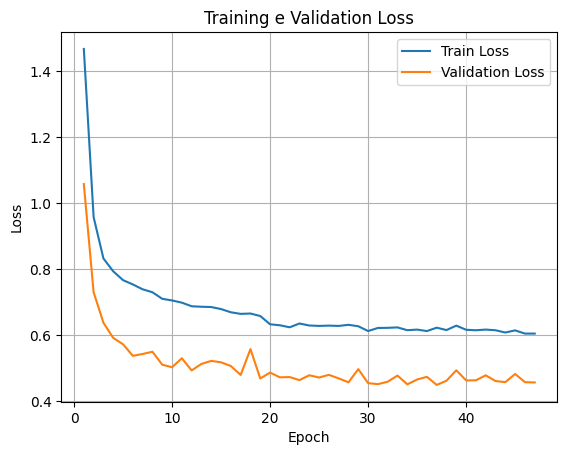

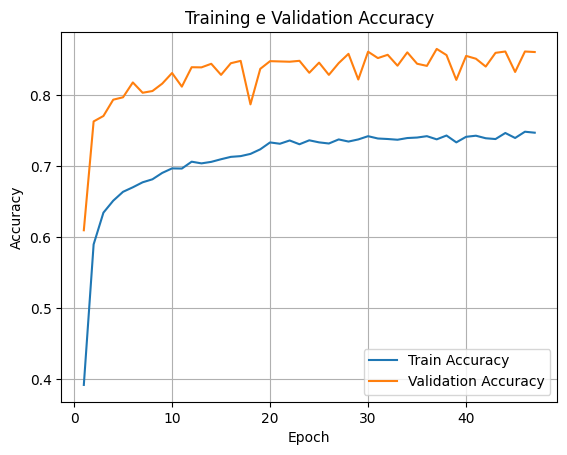

In [ ]:

epochs = range(1, len(history["train_loss"]) + 1)

# Loss
plt.figure()
plt.plot(epochs, history["train_loss"], label="Train Loss")
plt.plot(epochs, history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training e Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

# Accuracy
plt.figure()
plt.plot(epochs, history["train_acc"], label="Train Accuracy")
plt.plot(epochs, history["val_acc"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training e Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()


### Visualizzazione performance

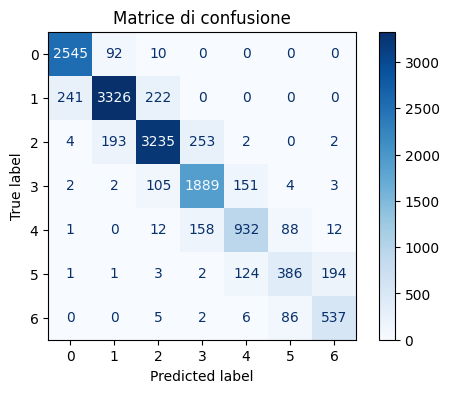

In [ ]:
y_test_np = y_test.cpu().numpy()
y_pred_np = y_pred_c.cpu().numpy()

cm = confusion_matrix(y_test_np, y_pred_np)

fig, ax = plt.subplots(figsize=(6, 4))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=range(7))
disp.plot(cmap='Blues', ax=ax)
plt.title("Matrice di confusione")
plt.show()